1. Постановка задачи.
2. Описание данных.
3. Подготовка данных.
4. Разделение на `train` / `validation` / `test`.
5. Выбор модели.
6. Обучение модели.
7. Графики `loss` / метрик.
8. Оценка на `test set`.

In [42]:
import os
import json
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. Постановка задачи

Тема: Обнаружение автомобилей на городских фотографиях (бинарная классификация)

Суть задачи:
По произвольному изображению уличной сцены определить, присутствует ли на нём хотя бы один автомобиль (легковой, грузовой, автобус — всё, что относится к классу Car в датасете).

Тип задачи: Бинарная классификация

Вход: Цветное изображение (после преобразования — размером 224×224 пикселя)

Выход:

1 (положительный класс) — на фото есть автомобиль

0 (отрицательный класс) — автомобилей нет

# 2. Описание датасета

https://www.kaggle.com/datasets/mohamedgobara/26-class-object-detection-dataset

Название: 26 Class Object Detection Dataset for Urban Scenes
Источник: Kaggle (Mohamed Gobara)
Размер: ~1.09 ГБ (38 900 файлов, из них ~35 000 фото)
Формат разметки: COCO JSON (подробные аннотации для каждого объекта на фото: координаты bounding box, класс)
Разделён на три папки:
train
valid
test
В папках изображения + _annotations.coco.json

Классы (26 объектов городской среды):
1. Bench
2. Bicycle
3. Branch
4. Bus
5. Bushes
6. Car
7. Crosswalk
8. Door
9. Elevator
10. Fire Hydrant
11. Green Light
12. Gun
13. Motorcycle
14. Person
15. Pothole
16. Rat
17. Red Light
18. Scooter
19. Stairs
20. Stop Sign
21. Traffic Cone
22. Train
23. Tree
24. Truck
25. Umbrella
26. Yellow Light



# 3. Подготовка данных

In [16]:
DATA_DIR = Path.cwd()
TRAIN_DIR = DATA_DIR / "Senior-Design-VIAD-4" / "train"
VALID_DIR = DATA_DIR / "Senior-Design-VIAD-4" / "valid"
TEST_DIR = DATA_DIR / "Senior-Design-VIAD-4" / "test"

In [17]:
def load_annotations(data_dir):
    """Загрузка COCO аннотаций из JSON файла"""
    json_path = None
    for f in data_dir.glob("*_annotations.coco.json"):
        json_path = f
        break
    
    if json_path is None:
        raise FileNotFoundError(f"No annotation file found in {data_dir}")
    
    with open(json_path, "r") as f:
        annotations = json.load(f)
    
    return annotations

In [21]:
train_ann = load_annotations(TRAIN_DIR)
valid_ann = load_annotations(VALID_DIR)
test_ann = load_annotations(TEST_DIR)

print(f"Train images: {len(train_ann['images'])}")
print(f"Valid images: {len(valid_ann['images'])}")
print(f"Test images: {len(test_ann['images'])}")

Train images: 32511
Valid images: 4246
Test images: 2165


In [38]:
def create_binary_labels(annotations):
    """
    Создает словарь: image_id: 1 если есть Car, иначе 0
    """
    car_image_ids = set()
    
    for ann in annotations['annotations']:
        category_id = ann['category_id']
        for cat in annotations['categories']:
            if cat['id'] == category_id and cat['name'] == 'car':
                car_image_ids.add(ann['image_id'])  # image_id - это id изображения
                break
    
    labels = {}
    for img in annotations['images']:
        file_name = img['file_name']
        labels[file_name] = 1 if img['id'] in car_image_ids else 0
    
    return labels, car_image_ids

In [39]:
train_labels, train_car_ids = create_binary_labels(train_ann)
valid_labels, valid_car_ids = create_binary_labels(valid_ann)
test_labels, test_car_ids = create_binary_labels(test_ann)

print(f"Train: {sum(train_labels.values())} car images, {len(train_labels) - sum(train_labels.values())} not car images")
print(f"Valid: {sum(valid_labels.values())} car images, {len(valid_labels) - sum(valid_labels.values())} not car images")
print(f"Test: {sum(test_labels.values())} car images, {len(test_labels) - sum(test_labels.values())} not car images")

Train: 1809 car images, 30702 not car images
Valid: 228 car images, 4018 not car images
Test: 107 car images, 2058 not car images


In [40]:
def create_folder_structure(data_dir, annotations, labels, output_dir):
    """
    Создает структуру папок для PyTorch ImageFolder:
    .../
        car/
        not_car/

    """
    img_paths = {}
    for img in annotations['images']:
        img_paths[img['id']] = img['file_name']
    
    for split in ['train', 'valid', 'test']:
        for cls in ['car', 'not_car']:
            (output_dir / split / cls).mkdir(parents=True, exist_ok=True)
    
    for file_name, label in labels.items():

        src_file = data_dir / file_name
        if not src_file.exists():
            print(f"Warning: {src_file} not found, skipping")
            continue
        
        split = None
        if data_dir == TRAIN_DIR:
            split = 'train'
        elif data_dir == VALID_DIR:
            split = 'valid'
        else:
            split = 'test'
        
        dest_dir = output_dir / split / ('car' if label == 1 else 'not_car')
        dest_file = dest_dir / src_file.name
        
        shutil.copy2(src_file, dest_file)

In [41]:
PROCESSED_DIR = Path("./processed_data")
for d in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    create_folder_structure(d, 
                           train_ann if d == TRAIN_DIR else valid_ann if d == VALID_DIR else test_ann,
                           train_labels if d == TRAIN_DIR else valid_labels if d == VALID_DIR else test_labels,
                           PROCESSED_DIR)

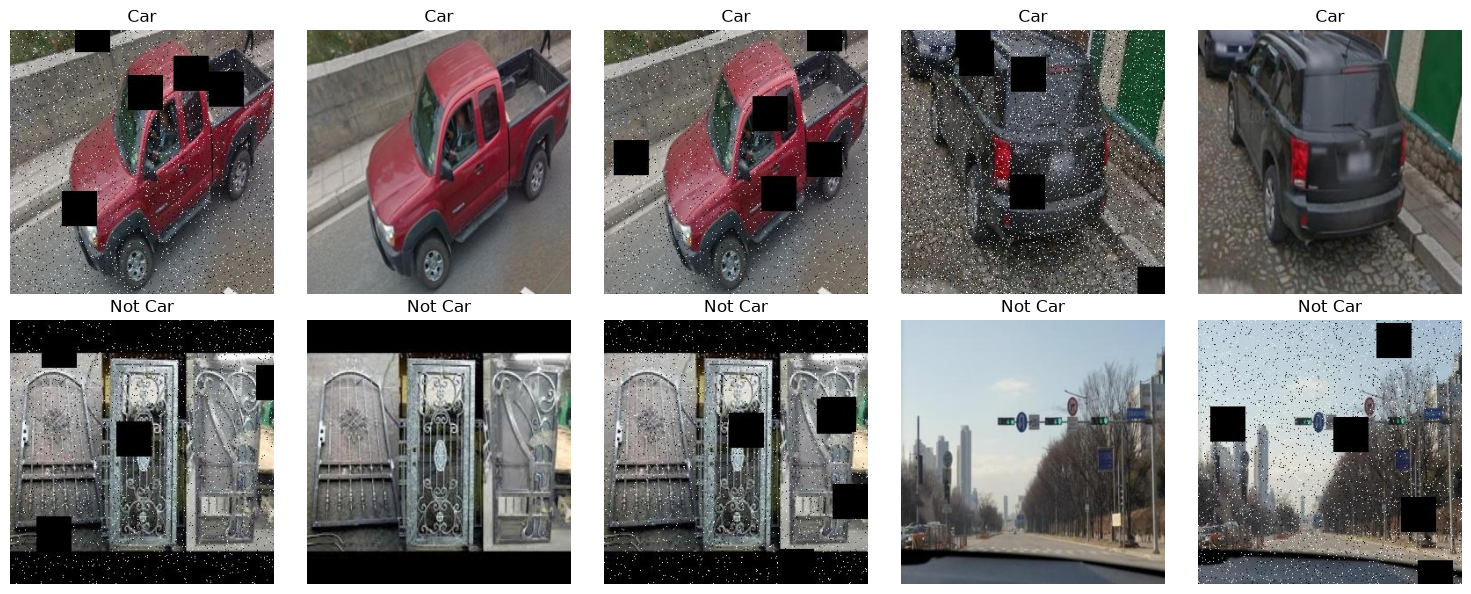

In [49]:
def show_samples(data_dir, num_samples=5):
    categories = {'car': 0, 'not_car': 1}
    
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    
    for category, row in categories.items():
        files = list((data_dir / 'train' / category).glob('*'))[:num_samples]
        for i, img_path in enumerate(files):
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            axes[row, i].imshow(img)
            axes[row, i].set_title(category.replace('_', ' ').title())
            axes[row, i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_samples(PROCESSED_DIR)

In [43]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Стандарт для ImageNet
])

In [44]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [46]:
train_dataset = datasets.ImageFolder(
    root=PROCESSED_DIR / 'train',
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=PROCESSED_DIR / 'valid',
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=PROCESSED_DIR / 'test',
    transform=val_test_transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Valid samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Train samples: 32511
Valid samples: 4246
Test samples: 2165
Classes: ['car', 'not_car']


In [58]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# 4. Разделение датасета

У меня уже разделен, но делалось бы как-то так:

```
from torch.utils.data import ConcatDataset, random_split

train_size = int(0.7 * len(full_loader))
val_size = int(0.15 * len(full_loader))
test_size = len(full_loader) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_loader, [train_size, val_size, test_size]
)
```

# 5. Выбор и обучение модели

### ResNet-18

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

In [50]:
from torchvision import models
import torch.nn as nn

def create_resnet18(num_classes=2, pretrained=True):
    """
    Создаёт модель ResNet-18 с заменой последнего слоя
    """
    # Загружаем предобученную модель (ImageNet веса)
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    
   
    for param in model.parameters():
        param.requires_grad = False
    
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    
    return model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Обучает модель одну эпоху"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc, all_preds, all_labels

def validate(model, loader, criterion, device):
    """Валидация модели"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc, all_preds, all_labels


In [55]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    """Полный цикл обучения с сохранением лучшей модели"""
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    
    for epoch in range(1, num_epochs + 1):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Обучение
        train_loss, train_acc, _, _ = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # Валидация
        val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Сохраняем лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"✓ New best model saved! (Acc: {val_acc:.4f})")
        
        # Обновляем scheduler
        if scheduler:
            scheduler.step(val_loss)
    
    return history, best_val_acc

In [61]:
import torch.optim as optim

if __name__ == "__main__":
    print(f"Device: {DEVICE}")

    model = create_resnet18(num_classes=2).to(DEVICE)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    history, best_acc = train_model(
        model, 
        train_loader,
        val_loader,
        criterion, 
        optimizer, 
        scheduler, 
        NUM_EPOCHS, 
        DEVICE
    )

Device: cpu
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track

Validation: 100%|██████████| 133/133 [01:31<00:00,  1.45it/s]


Train Loss: 0.1692, Train Acc: 0.9473
Val Loss: 0.1117, Val Acc: 0.9651
✓ New best model saved! (Acc: 0.9651)

Epoch 2/15
Learning Rate: 0.000100


Validation: 100%|██████████| 133/133 [01:30<00:00,  1.47it/s]


Train Loss: 0.1391, Train Acc: 0.9537
Val Loss: 0.1009, Val Acc: 0.9670
✓ New best model saved! (Acc: 0.9670)

Epoch 3/15
Learning Rate: 0.000100


...

Train Loss: 0.1119, Train Acc: 0.9640
Val Loss: 0.0880, Val Acc: 0.9743
✓ New best model saved! (Acc: 0.9743)

Epoch 14/15
Learning Rate: 0.000100


Validation: 100%|██████████| 133/133 [01:30<00:00,  1.47it/s]


Train Loss: 0.1106, Train Acc: 0.9629
Val Loss: 0.0840, Val Acc: 0.9727

Epoch 15/15
Learning Rate: 0.000100


Validation: 100%|██████████| 133/133 [01:30<00:00,  1.47it/s]

Train Loss: 0.1081, Train Acc: 0.9648
Val Loss: 0.0830, Val Acc: 0.9750
✓ New best model saved! (Acc: 0.9750)


In [62]:
train_losses = history['train_loss']
val_losses = history['val_loss']
val_accuracies = history['val_acc']

total_epochs = len(train_losses)
epochs_range = range(1, total_epochs + 1)

plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

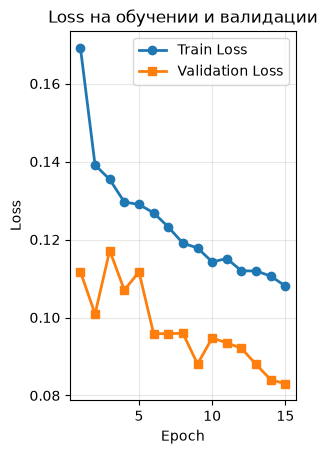

In [63]:
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss на обучении и валидации')
plt.grid(True, alpha=0.3)

In [68]:
print("Значения val_acc:", history.get('val_acc', []))


Ключи в history: dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])
Длина val_acc: 15
Значения val_acc: [0.9651436646255299, 0.9670277908619878, 0.9632595383890721, 0.9660857277437588, 0.9616109279321715, 0.9707960433349034, 0.9705605275553462, 0.9710315591144607, 0.9717381064531324, 0.9717381064531324, 0.9712670748940179, 0.9729156853509185, 0.9743287800282618, 0.9726801695713613, 0.9750353273669335]


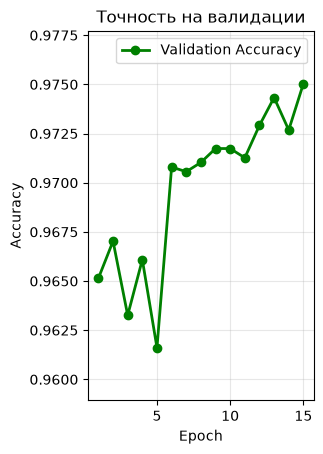

In [69]:
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green', marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Точность на валидации')

min_acc = min(val_accuracies)
max_acc = max(val_accuracies)
margin = (max_acc - min_acc) * 0.2  # 20
plt.ylim(min_acc - margin, max_acc + margin)

plt.grid(True, alpha=0.3)

In [67]:
print(f"\nВсего эпох: {total_epochs}")
print(f"Лучшая точность: {max(val_accuracies):.4f}")
print(f"Финальная точность: {val_accuracies[-1]:.4f}")


Всего эпох: 15
Лучшая точность: 0.9750
Финальная точность: 0.9750
